**-----------------------------------------------Applying ANNs on Churn dataset--------------------------------------------------------**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [ ]:
df = pd.read_csv('Churn_Modelling.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Performing EDA**

In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Checking for any null values

In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


Checking for any duplicate values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Finding categorical and numerical columns

In [ ]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

In [ ]:
categorical_cols

['Surname', 'Geography', 'Gender']

In [ ]:
numerical_cols = [col for col in df.columns if df[col].dtype != 'object' ]

In [ ]:
numerical_cols

['RowNumber',
 'CustomerId',
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [ ]:
from sklearn.preprocessing import OneHotEncoder

Applying One Hot Encoding on categorical columns

In [ ]:

encoder = OneHotEncoder(sparse_output=False,drop='first')
encoded_array = encoder.fit_transform(df[['Geography','Gender']])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Geography','Gender']))

print(encoded_df)

      Geography_Germany  Geography_Spain  Gender_Male
0                   0.0              0.0          0.0
1                   0.0              1.0          0.0
2                   0.0              0.0          0.0
3                   0.0              0.0          0.0
4                   0.0              1.0          0.0
...                 ...              ...          ...
9995                0.0              0.0          1.0
9996                0.0              0.0          1.0
9997                0.0              0.0          0.0
9998                1.0              0.0          1.0
9999                0.0              0.0          0.0

[10000 rows x 3 columns]


Merging or Concatinating the OHE Dataframe with orignal Dataframe.

In [ ]:
df_encoded = pd.concat(
    [df.drop(columns = ['Geography','Gender'], axis=1).reset_index(drop=True),  # Drop original categorical cols
     encoded_df.reset_index(drop=True)],                       # Add new encoded cols
    axis=1
)

In [ ]:
df_encoded.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,0.0,0.0,0.0
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0,0.0
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0,0.0
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,0.0,0.0,0.0
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0,0.0


In [ ]:
df.shape

(10000, 14)

In [ ]:
df_encoded.shape

(10000, 15)

In [ ]:
count = 0
for i in df_encoded.columns:
  # sns.histplot(df[i])
  print(i)
  count += 1

print(count)



RowNumber
CustomerId
Surname
CreditScore
Age
Tenure
Balance
NumOfProducts
HasCrCard
IsActiveMember
EstimatedSalary
Exited
Geography_Germany
Geography_Spain
Gender_Male
15


Basic visualization for understanding underlying distributions

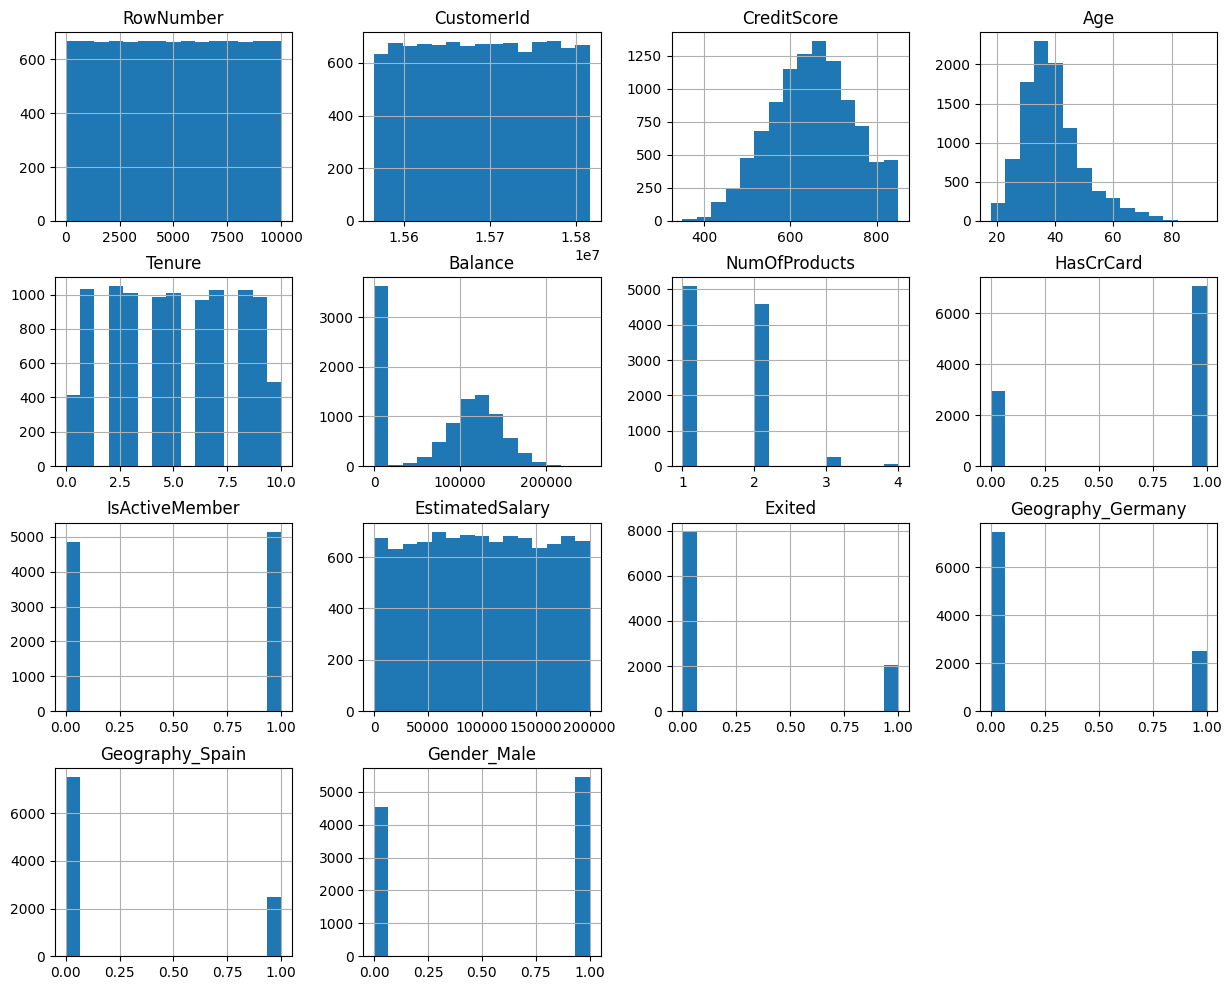

In [ ]:
df_encoded.hist(figsize=(15,12),bins = 15)
plt.title("Features Distribution")
plt.show()

<Axes: ylabel='Balance'>

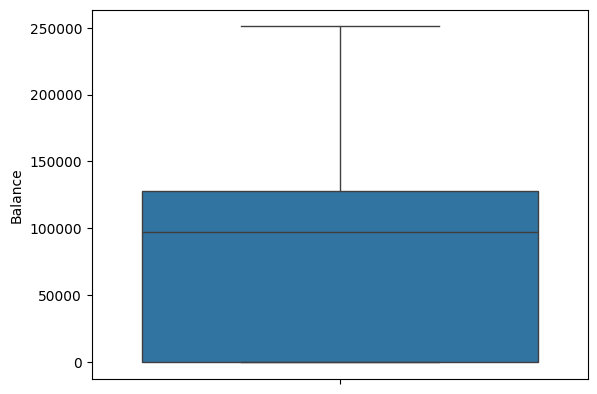

In [ ]:
sns.boxplot(df['Balance'])

<Axes: ylabel='Age'>

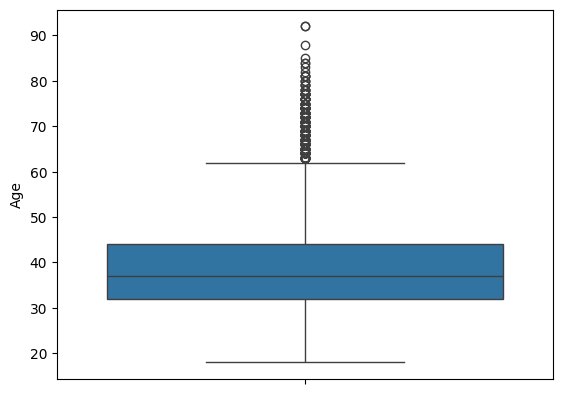

In [ ]:
sns.boxplot(df['Age'])

In [ ]:
df_encoded['Age'].min()

18

In [ ]:
df_encoded['Age'].max()

92

In [ ]:
df_encoded['Age'].mean()

np.float64(38.9218)

In [ ]:
df_encoded['Age'].median()

37.0

In [ ]:
# fig,ax = plt.subplots(nrows = 4, ncols=3, figsize=(30,30))
# row = 0
# col = 0
# for i in range(len(df_encoded.columns) -1):
#     if col > 2:
#         row += 1
#         col = 0
#     axes = ax[row,col]
#     sns.boxplot(x = df_encoded['Exited'], y = df_encoded[df_encoded.columns[i]],ax = axes)
#     col += 1
# plt.tight_layout()
# # plt.title("Individual Features by Class")
# plt.show()

In [ ]:
df_encoded['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


<Axes: xlabel='Exited'>

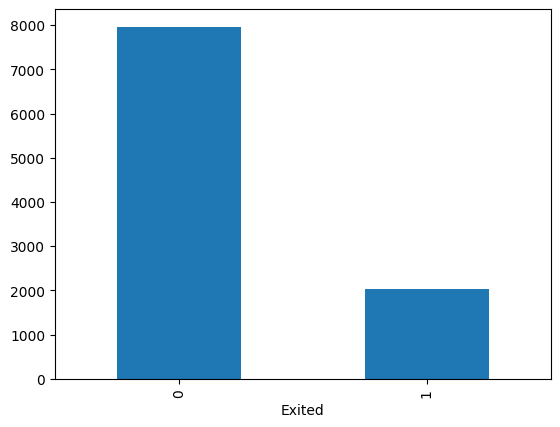

In [ ]:
df_encoded['Exited'].value_counts().plot(kind='bar')

In [ ]:
df_encoded.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,0.0,0.0,0.0
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0,0.0
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0,0.0
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,0.0,0.0,0.0
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0,0.0


Dropping irrelevant Columns

In [ ]:
df_encoded = df_encoded.drop(columns= ['RowNumber','CustomerId','Surname'], axis=1)

Viewing Correlation matrix to check for multicollinearity and feature importance

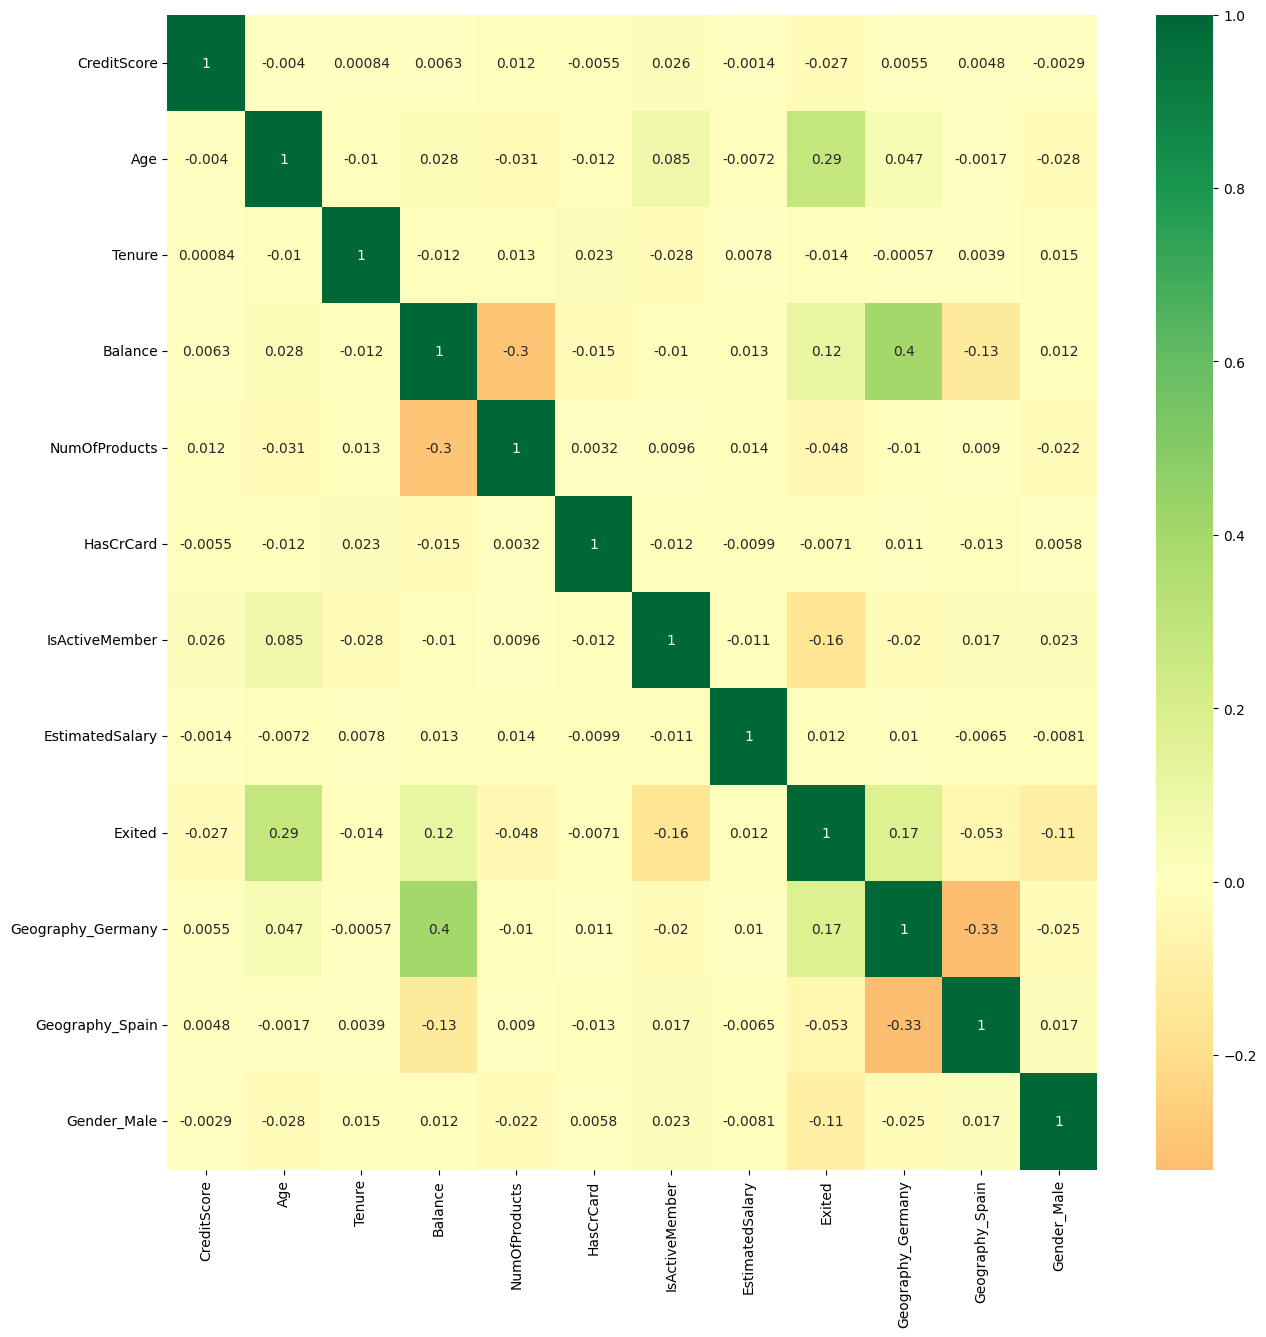

In [ ]:
plt.figure(figsize=(15,15))
p=sns.heatmap(df_encoded.corr(), annot=True,cmap='RdYlGn',center=0)

In [ ]:
X = df_encoded.drop(columns= ['Exited'], axis=1)
y = df_encoded['Exited']

In [ ]:
X.shape

(10000, 11)

Applying Scaling and splitting the dataset into training and testing data.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,0.0,0.0,1.0
1561,632,42,4,119624.60,2,1,1,195978.86,1.0,0.0,1.0
1670,559,24,3,114739.92,1,1,0,85891.02,0.0,1.0,1.0
6087,561,27,9,135637.00,1,1,0,153080.40,0.0,0.0,0.0
6669,517,56,9,142147.32,1,0,0,39488.04,0.0,0.0,1.0


In [ ]:
y_train.shape

(8000,)

In [ ]:
y_train.head()

,Exited
9254,0
1561,0
1670,1
6087,1
6669,1


In [ ]:
X_test.shape

(2000, 11)

Scalling the Data

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# sequential model to initialise our ann and dense module to build the layers
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.optimizers import Adam

Defining the ANN model architecture and by adding different layers

In [ ]:
model = Sequential()


model.add(Input(shape=(11,)))
model.add(Dense(32, activation='relu',kernel_initializer='he_normal'))

model.add(Dropout(0.20))
model.add(Dense(16, activation='relu'))


model.add(Dropout(0.4))
model.add(Dense(8, activation='relu'))


model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

Actual training of the model.

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                # Number of passes through the dataset
    batch_size=32,             # Number of samples per gradient update
    validation_data=(X_test_scaled, y_test),  # Validation to monitor performance
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6480 - loss: 0.6928 - val_accuracy: 0.8055 - val_loss: 0.4676
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7784 - loss: 0.5282 - val_accuracy: 0.8035 - val_loss: 0.4425
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8059 - loss: 0.4850 - val_accuracy: 0.8040 - val_loss: 0.4313
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7950 - loss: 0.4728 - val_accuracy: 0.8050 - val_loss: 0.4189
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8034 - loss: 0.4615 - val_accuracy: 0.8085 - val_loss: 0.4147
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7988 - loss: 0.4638 - val_accuracy: 0.8115 - val_loss: 0.4086
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8049 - loss: 0.4486 - val_accuracy: 0.8215 - val_loss: 0.4021
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8104 - loss: 0.4440 - val_accu

Visualizing the training and validation loss over epochs

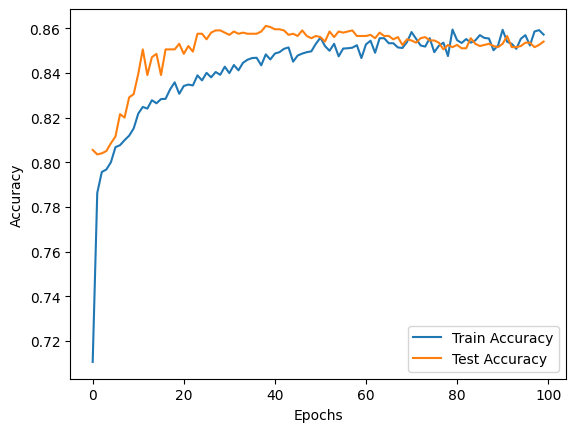

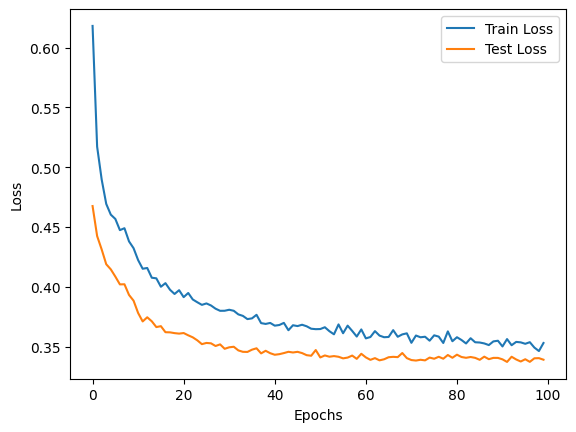

In [ ]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Evaluate model on unseen test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 85.40%
Test Loss: 0.3392


Plotting confusion matrix and other evaluation techniques

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [ ]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob >= 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


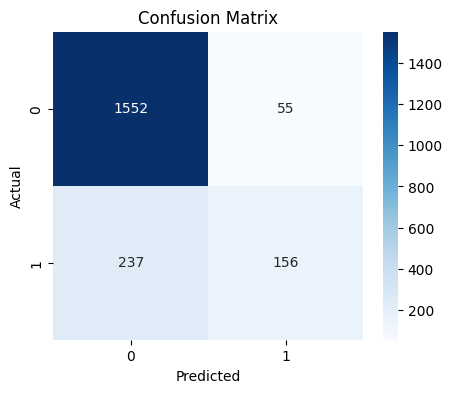

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1607
           1       0.74      0.40      0.52       393

    accuracy                           0.85      2000
   macro avg       0.80      0.68      0.72      2000
weighted avg       0.84      0.85      0.84      2000



In [ ]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")


ROC AUC Score: 0.8578
